In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.ensemble import RandomForestClassifier


#    Loading the data
df = pd.read_csv('creditcard.csv')

#    Checking the first lines
print("--- First 5 lines ---")
print(df.head())

#    Checking how many scams we have (Class 1 = Scam, 0 = Normal)
print("\n--- Transaction Allocation ---")
print(df['Class'].value_counts())

#    Fraud rate
fraud_p = (df['Class'].value_counts()[1] / len(df)) * 100
print(f"\nFraud Rate: {fraud_p:.4f}%")

--- First 5 lines ---
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V2


--- Statistics for Regular Transactions ---
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

--- Fraud Statistics ---
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


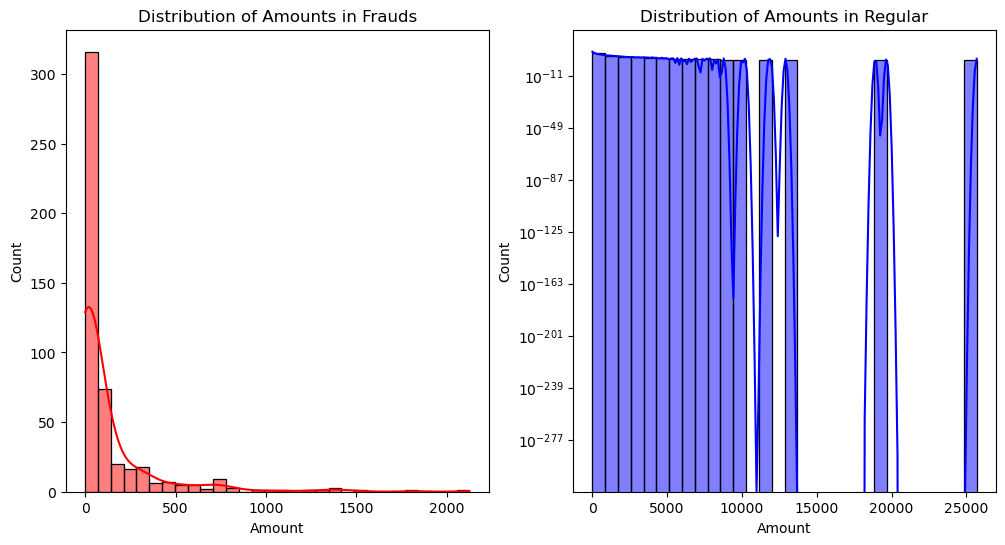

In [33]:
#   Comparison of amounts (Amount)
print("\n--- Statistics for Regular Transactions ---")
print(df[df['Class'] == 0]['Amount'].describe())

print("\n--- Fraud Statistics ---")
print(df[df['Class'] == 1]['Amount'].describe())

#  Visualizing Time vs Amount
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(df[df['Class'] == 1]['Amount'], bins=30, kde=True, color='red')
plt.title('Distribution of Amounts in Frauds')

plt.subplot(1, 2, 2)
sns.histplot(df[df['Class'] == 0]['Amount'], bins=30, kde=True, color='blue')
plt.title('Distribution of Amounts in Regular')
plt.yscale('log') # We use log scale because there are too many normal ones

plt.show()

In [34]:
# We scale Amount and Time
scaler = StandardScaler()
df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = scaler.fit_transform(df['Time'].values.reshape(-1,1))

# We throw away the old and keep the new
df.drop(['Time', 'Amount'], axis=1, inplace=True)

print("\nData was scaled successfully!")
print(df.head(2))


Data was scaled successfully!
         V1        V2        V3        V4        V5        V6        V7  \
0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   

         V8        V9       V10  ...       V22       V23       V24       V25  \
0  0.098698  0.363787  0.090794  ...  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425 -0.166974  ... -0.638672  0.101288 -0.339846  0.167170   

        V26       V27       V28  Class  scaled_amount  scaled_time  
0 -0.189115  0.133558 -0.021053      0       0.244964    -1.996583  
1  0.125895 -0.008983  0.014724      0      -0.342475    -1.996583  

[2 rows x 31 columns]



--- New Distribution ---
0    492
1    492
Name: Class, dtype: int64


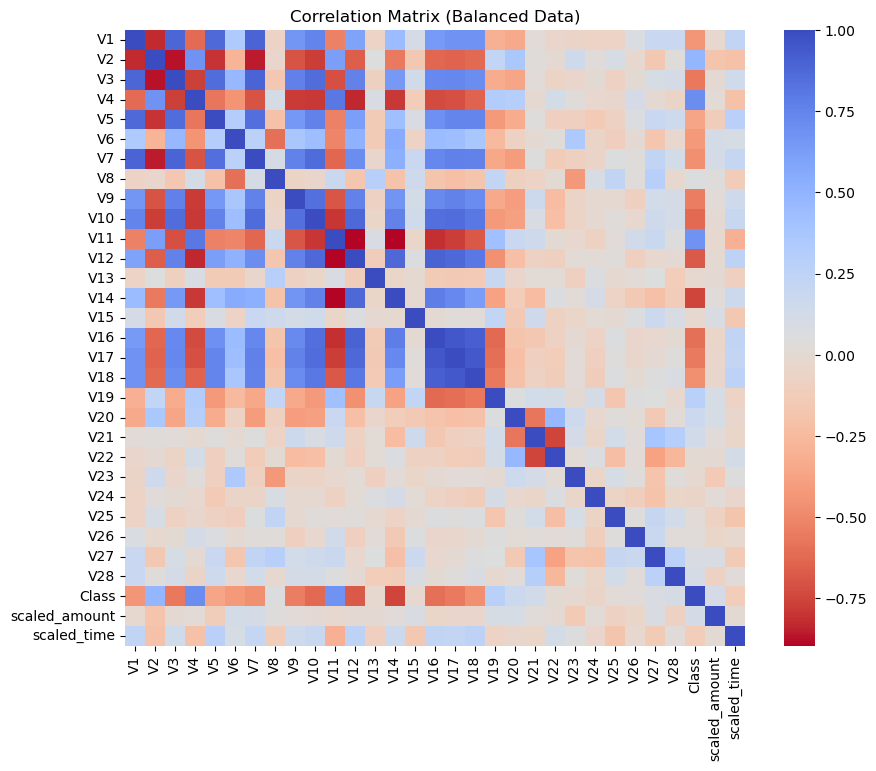

In [35]:
#  We shuffle the data
df = df.sample(frac=1)

#  We separate scams from regular ones
fraud_df = df.loc[df['Class'] == 1]
non_fraud_df = df.loc[df['Class'] == 0][:492] # We only get 492 random

#  Join the two parts into a new dataframe
balanced_df = pd.concat([fraud_df, non_fraud_df])

#  Shuffle the new dataframe again
new_df = balanced_df.sample(frac=1, random_state=42)

print("\n--- New Distribution ---")
print(new_df['Class'].value_counts())

#  See the correlation in the new dataset
plt.figure(figsize=(10, 8))
sns.heatmap(new_df.corr(), cmap='coolwarm_r', annot=False)
plt.title('Correlation Matrix (Balanced Data)')
plt.show()

In [36]:
# We divide the data into Features (X) and Target (y)
X = new_df.drop('Class', axis=1)
y = new_df['Class']

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creating and Training the Model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Results
print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

--- Confusion Matrix ---
[[86  1]
 [11 99]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.89      0.99      0.93        87
           1       0.99      0.90      0.94       110

    accuracy                           0.94       197
   macro avg       0.94      0.94      0.94       197
weighted avg       0.94      0.94      0.94       197



In [37]:
# We get all the features from the original, large dataset
X_original = df.drop('Class', axis=1)
y_original = df['Class']

# We make predictions on ALL data
y_pred_original = model.predict(X_original)

# Show results for the entire dataset
print("--- Results on Original (Imbalanced) Dataset ---")
print(confusion_matrix(y_original, y_pred_original))
print(classification_report(y_original, y_pred_original))

--- Results on Original (Imbalanced) Dataset ---
[[274421   9894]
 [    36    456]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.98    284315
           1       0.04      0.93      0.08       492

    accuracy                           0.97    284807
   macro avg       0.52      0.95      0.53    284807
weighted avg       1.00      0.97      0.98    284807



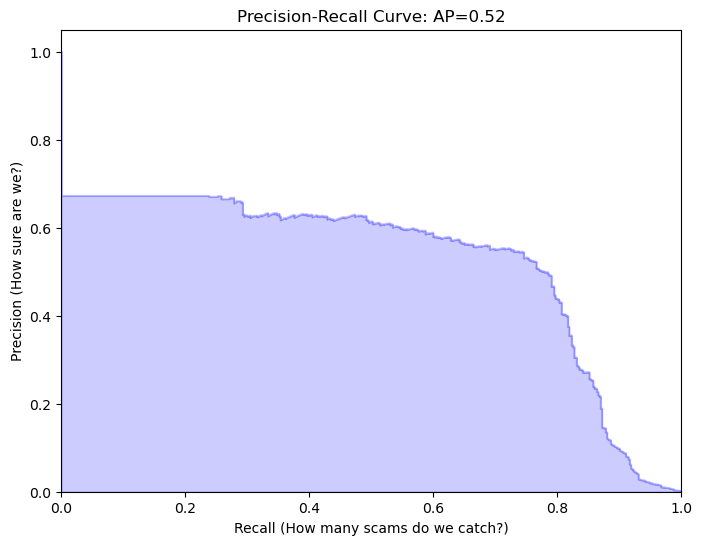

In [38]:
# We calculate probabilities (not just 0 or 1)
y_scores = model.predict_proba(X_original)[:, 1]

# We calculate Precision and Recall for various thresholds
precision, recall, thresholds = precision_recall_curve(y_original, y_scores)
average_precision = average_precision_score(y_original, y_scores)

# Drawing the chart
plt.figure(figsize=(8, 6))
plt.step(recall, precision, color='b', alpha=0.2, where='post')
plt.fill_between(recall, precision, step='post', alpha=0.2, color='b')

plt.xlabel('Recall (How many scams do we catch?)')
plt.ylabel('Precision (How sure are we?)')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title(f'Precision-Recall Curve: AP={average_precision:.2f}')
plt.show()

In [39]:
#  We create a DataFrame with the final results
final_results = pd.DataFrame({
    'Actual_Class': y_original,
    'Fraud_Probability': y_scores
})

# Save to CSV for future use (or for Power BI!)
final_results.to_csv('fraud_predictions_final.csv', index=False)

print("The file 'fraud_predictions_final.csv' has been created!")
print("You can open it in Excel to see which transactions have a high score!")

The file 'fraud_predictions_final.csv' has been created!
You can open it in Excel to see which transactions have a high score!


In [40]:
#  Creating the model (we put 100 trees)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

#  Training (we use the balanced_df we created before)
rf_model.fit(X_train, y_train)

#  Probability predictions for the entire dataset
y_scores_rf = rf_model.predict_proba(X_original)[:, 1]

#  Calculating a new AP score
new_ap_rf = average_precision_score(y_original, y_scores_rf)

print(f"Old AP (Logistic Regression): {average_precision:.2f}")
print(f"New AP (Random Forest): {new_ap_rf:.2f}")

# Confusion Matrix comparison in the real world
y_pred_rf = rf_model.predict(X_original)
print("\n--- New Confusion Matrix (RF) ---")
print(confusion_matrix(y_original, y_pred_rf))

Old AP (Logistic Regression): 0.52
New AP (Random Forest): 0.80

--- New Confusion Matrix (RF) ---
[[276900   7415]
 [    13    479]]


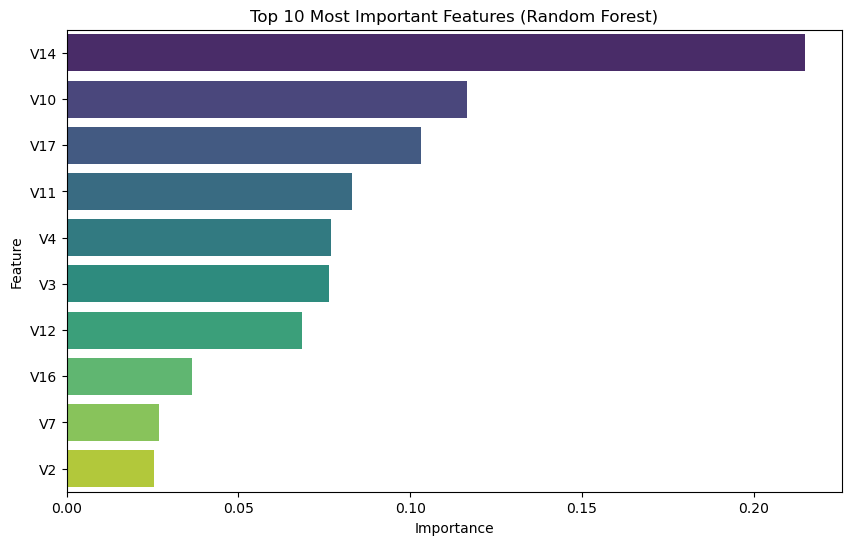

In [41]:
#  We take the importance of features
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

#  Chart (Top 10)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')
plt.title('Top 10 Most Important Features (Random Forest)')
plt.show()

In [42]:
# We create the final file for Power BI
pbi_fraud = df.copy()
pbi_fraud['Probability'] = y_scores_rf
pbi_fraud['Prediction'] = y_pred_rf

# Save
pbi_fraud.to_csv('fraud_analysis_for_pbi.csv', index=False)
print("The file is ready for Power BI!")

The file is ready for Power BI!


### Quant Parameters

In [43]:
# Define the costs (Quant Parameters)
cost_per_alert = 0.1      # How many euros does the bank pay employees for each check?
fraud_penalty_multiplier = 1.0  # The damage from a lost fraud (the amount + 20% fines)

print("Quant parameters are set!")

Quant parameters are set!


In [44]:
# Create a dataframe with only what is needed for Quant
# Use the index of y_test to pull the correct lines from the original df
quant_df = df.loc[y_test.index, ['Class', 'scaled_amount']]

# We make sure the odds are ready
model_probabilities = rf_model.predict_proba(X_test)[:, 1]

In [45]:
thresholds = np.linspace(0, 1, 101)
profits = []

for t in thresholds:
    # Predictions for this threshold
    temp_preds = (model_probabilities >= t).astype(int)
    
    # Convert to Series to match index with quant_df
    preds_series = pd.Series(temp_preds, index=quant_df.index)
    
    # Cost of Inspections
    ops_cost = temp_preds.sum() * cost_per_alert
    
    # Saved Amount: Scams we actually caught (Class=1 and Pred=1)
    saved_amt = quant_df[(quant_df['Class'] == 1) & (preds_series == 1)]['scaled_amount'].sum()
    
    # Missed Amount: Frauds we missed (Class=1 and Pred=0)
    missed_amt = quant_df[(quant_df['Class'] == 1) & (preds_series == 0)]['scaled_amount'].sum() * fraud_penalty_multiplier
    
    # Net Profit
    net_profit = saved_amt - ops_cost - missed_amt
    profits.append(net_profit)

# Results
best_index = np.argmax(profits)
print("-" * 30)
print(f"QUANT RESULTS")
print("-" * 30)
print(f"Best Threshold: {thresholds[best_index]:.2f}")
print(f"Max Net Profit: {profits[best_index]:.2f}€")
print("-" * 30)

------------------------------
QUANT RESULTS
------------------------------
Best Threshold: 0.29
Max Net Profit: 2.08€
------------------------------
